In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsbombpy import sb
from mplsoccer import Pitch 

print("All imports working")

All imports working


In [6]:
# Display settings

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [4]:
# See whats available

competitions = sb.competitions()
print(f"Total competition/season combinations: {len(competitions)}")
competitions.head(10)

Total competition/season combinations: 75


,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-07-06T04:26:07.636270,2025-07-06T04:26:07.636270,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,NaN,NaN,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2024-09-28T01:57:35.846538,NaN,NaN,2024-09-28T01:57:35.846538
3,16,4,Europe,Champions League,male,False,False,2018/2019,2025-05-08T15:10:50.835274,2021-06-13T16:17:31.694,NaN,2025-05-08T15:10:50.835274
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,NaN,2024-02-13T02:35:28.134882
5,16,2,Europe,Champions League,male,False,False,2016/2017,2024-02-13T02:37:32.205154,2021-06-13T16:17:31.694,NaN,2024-02-13T02:37:32.205154
6,16,27,Europe,Champions League,male,False,False,2015/2016,2024-06-12T07:45:38.786894,2021-06-13T16:17:31.694,NaN,2024-06-12T07:45:38.786894
7,16,26,Europe,Champions League,male,False,False,2014/2015,2024-02-12T12:49:54.914228,2021-06-13T16:17:31.694,NaN,2024-02-12T12:49:54.914228
8,16,25,Europe,Champions League,male,False,False,2013/2014,2024-02-12T12:48:48.479157,2021-06-13T16:17:31.694,NaN,2024-02-12T12:48:48.479157
9,16,24,Europe,Champions League,male,False,False,2012/2013,2024-02-12T12:47:34.340413,2021-06-13T16:17:31.694,NaN,2024-02-12T12:47:34.340413


In [7]:
# Filter for mens competitions

mens_competitions = competitions[competitions['competition_gender'] == 'male']
print(f"Men's competition/season combinations: {len(mens_competitions)}")
mens_competitions[['competition_name', 'season_name', 'competition_id', 'season_id']]

Men's competition/season combinations: 67


,competition_name,season_name,competition_id,season_id
0,1. Bundesliga,2023/2024,9,281
1,1. Bundesliga,2015/2016,9,27
2,African Cup of Nations,2023,1267,107
3,Champions League,2018/2019,16,4
4,Champions League,2017/2018,16,1
5,Champions League,2016/2017,16,2
6,Champions League,2015/2016,16,27
7,Champions League,2014/2015,16,26
8,Champions League,2013/2014,16,25
9,Champions League,2012/2013,16,24


In [9]:
# Choosing World Cup 2022

wc22 = mens_competitions[
    (mens_competitions['competition_name'] == 'FIFA World Cup') & 
    (mens_competitions['season_name'] == '2022')
    ]

wc22

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
29,43,106,International,FIFA World Cup,male,False,True,2022,2024-12-16T10:15:11.055845,2024-12-16T10:21:13.710934,2024-12-16T10:21:13.710934,2024-12-16T10:15:11.055845


In [12]:
# Pulling matches

comp_id = wc22['competition_id'].iloc[0]
season_id = wc22['season_id'].iloc[0]

matches = sb.matches(competition_id=comp_id, season_id=season_id)
print(f"Total matches: {len(matches)}")
matches

Total matches: 64


,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,competition_id,competition_country_name,competition_name,competition,season_id,season,home_team_id,home_team,home_team_gender,home_team_group,home_team_country_id,home_team_country_name,away_team_id,away_team,away_team_gender,away_team_group,away_team_country_id,away_team_country_name,competition_stage_id,competition_stage,stadium_id,stadium,stadium_country_id,stadium_country_name,referee_id,referee,referee_country_id,referee_country_name,home_managers,away_managers,home_manager_id,home_manager_name,home_manager_nickname,home_manager_dob,home_manager_country_id,home_manager_country_name,away_manager_id,away_manager_name,away_manager_nickname,away_manager_dob,away_manager_country_id,away_manager_country_name,data_version,shot_fidelity_version,xy_fidelity_version
0,3857256,2022-12-02,21:00:00.000,2,3,available,available,2023-02-17T23:45:15.306706,2023-04-26T23:49:58.956186,3,43,International,FIFA World Cup,International - FIFA World Cup,106,2022,786,Serbia,male,G,203,Serbia,773,Switzerland,male,G,221,Switzerland,10,Group Stage,1001115,Stadium 974,185,Qatar,1121.0,Fernando Andrés Rapallini,11.0,Argentina,Dragan Stojković,Murat Yakin,5908,Dragan Stojković,NaN,1965-03-03,203,Serbia,2832,Murat Yakin,NaN,1974-09-15,221,Switzerland,1.1.0,2,2
1,3869151,2022-12-03,21:00:00.000,2,1,available,available,2023-07-30T07:46:05.382784,2023-07-30T07:48:51.865595,4,43,International,FIFA World Cup,International - FIFA World Cup,106,2022,779,Argentina,male,NaN,11,Argentina,792,Australia,male,NaN,14,Australia,33,Round of 16,1000793,Ahmad bin Ali Stadium,185,Qatar,367.0,Szymon Marciniak,182.0,Poland,Lionel Sebastián Scaloni,Graham James Arnold,5677,Lionel Sebastián Scaloni,NaN,1978-05-16,11,Argentina,5696,Graham James Arnold,NaN,1963-08-03,14,Australia,1.1.0,2,2
2,3857257,2022-11-30,17:00:00.000,1,0,available,available,2023-04-28T17:13:10.958725,2023-06-20T11:04:37.638969,3,43,International,FIFA World Cup,International - FIFA World Cup,106,2022,792,Australia,male,D,14,Australia,776,Denmark,male,D,61,Denmark,10,Group Stage,117897,Al Janoub Stadium,185,Qatar,2311.0,Mustapha Ghorbal,4.0,Algeria,Graham James Arnold,Kasper Hjulmand,5696,Graham James Arnold,NaN,1963-08-03,14,Australia,255,Kasper Hjulmand,NaN,1972-04-09,61,Denmark,1.1.0,2,2
3,3857258,2022-11-24,21:00:00.000,2,0,available,available,2023-06-24T17:17:27.911026,2023-07-11T14:56:31.096588,1,43,International,FIFA World Cup,International - FIFA World Cup,106,2022,781,Brazil,male,G,31,Brazil,786,Serbia,male,G,203,Serbia,10,Group Stage,1001114,Lusail Stadium,185,Qatar,741.0,Alireza Faghani,107.0,"Iran, Islamic Republic of",Telê Santana da Silva,Dragan Stojković,4704,Telê Santana da Silva,Telê Santana,1931-07-26,31,Brazil,5908,Dragan Stojković,NaN,1965-03-03,203,Serbia,1.1.0,2,2
4,3857288,2022-11-26,12:00:00.000,0,1,available,available,2023-02-28T21:25:20.888552,2023-04-27T00:30:07.835815,2,43,International,FIFA World Cup,International - FIFA World Cup,106,2022,777,Tunisia,male,D,232,Tunisia,792,Australia,male,D,14,Australia,10,Group Stage,117897,Al Janoub Stadium,185,Qatar,225.0,Daniel Siebert,85.0,Germany,Jalel Kadri,Graham James Arnold,1001303,Jalel Kadri,NaN,NaN,232,Tunisia,5696,Graham James Arnold,NaN,1963-08-03,14,Australia,1.1.0,2,2
5,3857267,2022-11-29,17:00:00.000,1,2,available,available,2023-03-11T17:17:56.123509,2023-05-19T13:52:07.885530,3,43,International,FIFA World Cup,International - FIFA World Cup,106,2022,3565,Ecuador,male,A,65,Ecuador,787,Senegal,male,A,202,Senegal,10,Group Stage,1000253,Sheikh Khalifa International Stadium,185,Qatar,76.0,Clément Turpin,78.0,France,Gustavo Julio Alfaro,Aliou Cissé,2881,Gustavo Julio Alfaro,Gustavo Alfaro,1962-08-14,11,Argentina,635,Aliou Cissé,NaN,1976-03-24,202,Senegal,1.1.0,2,2
6,3869321,2022-12-09,21:00:00.000,2,2,available,available,2023-03-30T20:22:22.475740,2023-06-21T17:51:12.511460,5,43,International,FIFA World Cup,Inter

In [13]:
# Pulling Final

final = matches[
    (matches['home_team'] == 'Argentina') & (matches['away_team'] == 'France')
    ]

final

,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,competition_id,competition_country_name,competition_name,competition,season_id,season,home_team_id,home_team,home_team_gender,home_team_group,home_team_country_id,home_team_country_name,away_team_id,away_team,away_team_gender,away_team_group,away_team_country_id,away_team_country_name,competition_stage_id,competition_stage,stadium_id,stadium,stadium_country_id,stadium_country_name,referee_id,referee,referee_country_id,referee_country_name,home_managers,away_managers,home_manager_id,home_manager_name,home_manager_nickname,home_manager_dob,home_manager_country_id,home_manager_country_name,away_manager_id,away_manager_name,away_manager_nickname,away_manager_dob,away_manager_country_id,away_manager_country_name,data_version,shot_fidelity_version,xy_fidelity_version
9,3869685,2022-12-18,17:00:00.000,3,3,available,available,2023-02-20T07:27:19.374380,2023-08-17T15:55:15.164685,7,43,International,FIFA World Cup,International - FIFA World Cup,106,2022,779,Argentina,male,NaN,11,Argentina,771,France,male,NaN,78,France,26,Final,1001114,Lusail Stadium,185,Qatar,367.0,Szymon Marciniak,182.0,Poland,Lionel Sebastián Scaloni,Didier Deschamps,5677,Lionel Sebastián Scaloni,NaN,1978-05-16,11,Argentina,545,Didier Deschamps,NaN,1968-10-15,78,France,1.1.0,2,2


In [15]:
# Load match events 

final_id = final['match_id'].iloc[0]
events = sb.events(match_id=final_id)

print(f"Total events: {len(events)}")
print(f"Columns: {len(events.columns)}")

# prints amount of event type occurences 
events['type'].value_counts()

Total events: 4407
Columns: 94


type
Pass               1263
Ball Receipt*      1114
Carry               940
Pressure            361
Ball Recovery       115
Duel                 98
Dribble              54
Block                50
Foul Committed       48
Clearance            45
Foul Won             44
Goal Keeper          44
Shot                 38
Miscontrol           35
Dispossessed         34
Dribbled Past        31
Interception         28
Substitution         13
Half Start           10
Half End             10
Injury Stoppage       9
50/50                 8
Tactical Shift        7
Starting XI           2
Bad Behaviour         2
Player Off            1
Player On             1
Offside               1
Shield                1
Name: count, dtype: int64

In [16]:
# Filtering to just the shots 

shots = events[events['type'] == 'Shot'].copy()

print(f"Total shots in the final: {len(shots)}")

shots

Total shots in the final: 38


,50_50,bad_behaviour_card,ball_receipt_outcome,ball_recovery_offensive,ball_recovery_recovery_failure,block_deflection,block_offensive,carry_end_location,clearance_aerial_won,clearance_body_part,clearance_head,clearance_left_foot,clearance_other,clearance_right_foot,counterpress,dribble_nutmeg,dribble_outcome,dribble_overrun,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_offensive,foul_committed_penalty,foul_committed_type,foul_won_advantage,foul_won_defensive,foul_won_penalty,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_technique,goalkeeper_type,id,index,interception_outcome,location,match_id,minute,off_camera,out,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_body_part,pass_cross,pass_deflected,pass_end_location,pass_goal_assist,pass_height,pass_inswinging,pass_length,pass_outcome,pass_outswinging,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_technique,pass_through_ball,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_end_location,shot_first_time,shot_freeze_frame,shot_key_pass_id,shot_one_on_one,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
4207,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.948190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,545c2c84-018f-4570-a01c-753823feaeac,192,NaN,"[92.4, 30.0]",3869685,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,Alexis Mac Allister,27886.0,Left Center Midfield,14,Argentina,779,[109b23ae-6cc9-49d7-888c-0ef1302b8abd],40,NaN,Right Foot,"[117.3, 38.3, 0.8]",NaN,"[{'location': [101.0, 48.0], 'player': {'id': ...",b8d55d4b-37dc-4491-ad9c-baa235eec9df,NaN,Saved,0.024542,Normal,Open Play,NaN,NaN,NaN,NaN,NaN,Argentina,779,00:04:40.798,Shot,NaN
4208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.422018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4ad26294-8aaf-4d69-83dd-bbf9ef797b32,340,NaN,"[99.2, 47.9]",3869685,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,Rodrigo Javier De Paul,7797.0,Right Center Midfield,18,Argentina,779,"[2e25cc68-01db-4b04-87b8-511991b3706f, a3062cb...",36,NaN,Right Foot,"[108.1, 40.4]",NaN,"[{'location': [88.4, 47.6], 'player': {'id': 3...",a2ce05f8-e1cd-4efb-865a-257a45a38cc0,NaN,Blocked,0.062813,Normal,Open Play,NaN,NaN,NaN,NaN,NaN,Argentina,779,00:07:36.537,Shot,NaN
4209,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.872980,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6d498191-05f0-432c-8764-03aea4ef9fb8,602,NaN,"[103.1, 34.6]",3869685,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,Ángel Fabián Di María Hernández,2995.0,Left Wing,27,Argentina,779,[f5b6061e-0674-471a-9725-a1ba88489e5f],15,NaN,Right Foot,"[120.0, 39.6, 7.5]",True,"[{'location': [117.8, 39.5], 'player': {'id': ...",NaN,NaN,Off T,0.106801,Normal,Open Play,NaN,NaN,NaN,NaN,NaN,Argentina,779,00:16:15.886,Shot,NaN
4210,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.625635,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6d527ebc-a948-4cd8-ac82-daced35bb715,771,NaN,"[108.0, 40.0]",3869685,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Other,Lionel Andrés Messi Cuccittini,5503.0,Right Wing,32,Argentina,779,[c9b8e568-dcdc-4302-9683-0e9e9a55a42a],24,NaN,Left Foot,"[120.0, 41.8, 0.2]",NaN,NaN,NaN,NaN,Goal,0.783500,Normal,Penalty,NaN,NaN,NaN,NaN,NaN,Argentina,779,00:22:24.114,Shot,NaN
4211,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

In [22]:
location_end = shots['shot_end_location']
location

4207    [117.3, 38.3, 0.8]
4208         [108.1, 40.4]
4209    [120.0, 39.6, 7.5]
4210    [120.0, 41.8, 0.2]
4211         [112.3, 80.0]
4212    [120.0, 41.7, 0.5]
4213    [117.6, 41.6, 1.3]
4214    [119.4, 35.8, 0.2]
4215    [120.0, 45.5, 1.5]
4216    [120.0, 31.5, 1.1]
4217    [120.0, 38.8, 4.5]
4218    [117.8, 40.4, 1.7]
4219    [120.0, 37.3, 0.3]
4220    [120.0, 41.5, 0.3]
4221         [101.8, 38.1]
4222         [100.7, 33.5]
4223    [118.0, 36.6, 0.2]
4224    [117.6, 39.3, 2.3]
4225    [120.0, 28.0, 0.3]
4226         [103.3, 40.4]
4227         [110.6, 44.2]
4228         [112.7, 41.0]
4229    [120.0, 34.9, 0.6]
4230    [119.0, 43.9, 0.2]
4231    [118.7, 44.1, 1.8]
4232    [120.0, 40.9, 0.3]
4233         [104.5, 29.1]
4234    [120.0, 36.7, 1.1]
4235    [109.7, 44.1, 0.5]
4236    [120.0, 46.5, 1.5]
4237    [120.0, 37.6, 1.3]
4238    [120.0, 38.3, 0.2]
4239    [118.8, 38.2, 0.9]
4240    [120.0, 40.4, 0.2]
4241    [120.0, 35.6, 0.2]
4242    [120.0, 37.6, 0.2]
4243    [120.0, 39.3, 1.6]
4

In [23]:
# Seeing what proportion of shats have freeze frames

shots['has_freeze_frame'] = shots['shot_freeze_frame'].apply(
    lambda x: isinstance(x, list) and len(x) > 0
)

print(shots['has_freeze_frame'].value_counts())

has_freeze_frame
True     28
False    10
Name: count, dtype: int64


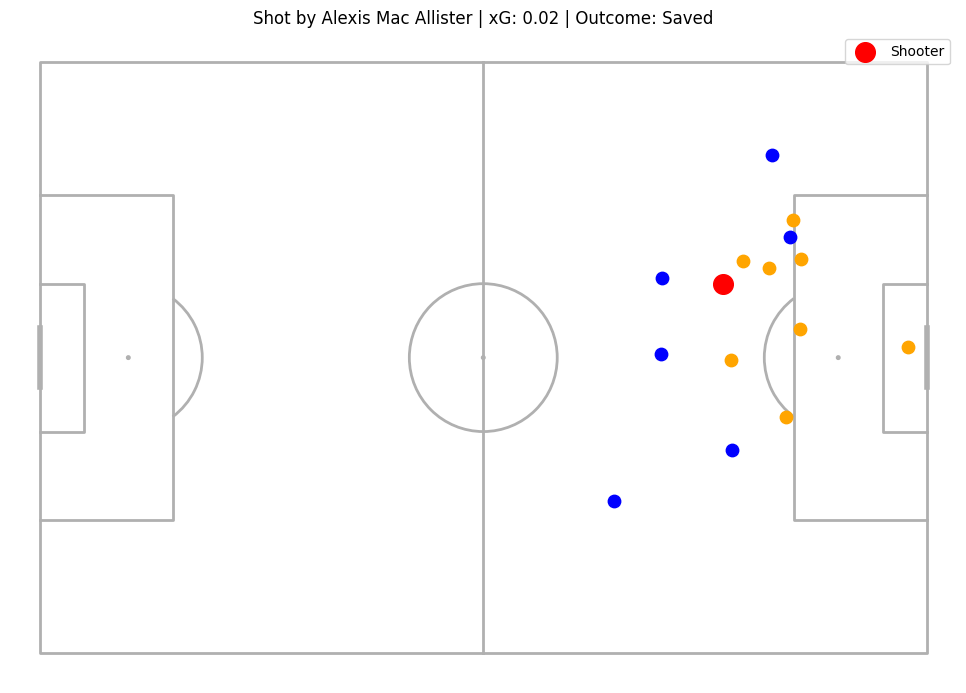

In [41]:
# Visualising shots

# Picking shot

shot = shots[shots['location'].apply(lambda l: l[0] < 100)].iloc[0]

shot_loc = shot['location']
freeze_frame = shot['shot_freeze_frame']

# Setting up pitch 
pitch = Pitch(pitch_type='statsbomb')
fig, ax = pitch.draw(figsize=(10, 7))

#Plotting shooter
pitch.scatter(shot_loc[0], shot_loc[1], ax=ax, color='red', s=200, label='Shooter')

#Plotting teammates and opponents 
for player in freeze_frame:
    loc = player['location']
    color = 'blue' if player['teammate'] else 'orange'
    pitch.scatter(loc[0], loc[1], ax=ax, color=color, s=80, zorder=2)

ax.set_title(f"Shot by {shot['player']} | xG: {shot['shot_statsbomb_xg']:.2f} | Outcome: {shot['shot_outcome']}")
plt.legend()
plt.show()

Adding Computed Columns 

In [43]:
# Add useful computed columns to the shots dataframe 

shots['x'] = shots['location'].apply(lambda l: l[0])
shots['y'] = shots['location'].apply(lambda l: l[1])
shots['distance_to_goal'] = np.sqrt(
    (120 - shots['x'])**2 + (40 - shots['y'])**2
)

shots[['player', 'x', 'y', 'distance_to_goal', 'shot_outcome', 'shot_statsbomb_xg']]

,player,x,y,distance_to_goal,shot_outcome,shot_statsbomb_xg
4207,Alexis Mac Allister,92.4,30.0,29.355749,Saved,0.024542
4208,Rodrigo Javier De Paul,99.2,47.9,22.249719,Blocked,0.062813
4209,Ángel Fabián Di María Hernández,103.1,34.6,17.741759,Off T,0.106801
4210,Lionel Andrés Messi Cuccittini,108.0,40.0,12.000000,Goal,0.783500
4211,Alexis Mac Allister,94.3,23.5,30.540792,Wayward,0.010578
4212,Ángel Fabián Di María Hernández,111.8,32.1,11.386395,Goal,0.303409
4213,Rodrigo Javier De Paul,103.3,52.3,20.740781,Saved,0.040216
4214,Julián Álvarez,110.5,24.9,17.839843,Saved,0.059534
4215,Lionel Andrés Messi Cuccittini,109.7,46.0,11.920151,Off T,0.115560
4216,Randal Kolo Muani,113.4,34.6,8.527602,Off T,0.096184


Defining Filter Dictionary 

In [44]:
shot_filters = {
    'headers':     lambda df: df[df['shot_body_part'] == 'Head'],
    'left_foot':   lambda df: df[df['shot_body_part'] == 'Left Foot'],
    'right_foot':  lambda df: df[df['shot_body_part'] == 'Right Foot'],
    'penalties':   lambda df: df[df['shot_type'] == 'Penalty'],
    'open_play':   lambda df: df[df['shot_type'] == 'Open Play'],
    'free_kicks':  lambda df: df[df['shot_type'] == 'Free Kick'],
    'long_shots':  lambda df: df[df['distance_to_goal'] > 20],
    'inside_box':  lambda df: df[(df['x'] >= 102) & (df['y'].between(18, 62))],
    'goals':       lambda df: df[df['shot_outcome'] == 'Goal'],
    'saved':       lambda df: df[df['shot_outcome'] == 'Saved'],
    'high_xg':     lambda df: df[df['shot_statsbomb_xg'] > 0.3],
    'low_xg':      lambda df: df[df['shot_statsbomb_xg'] < 0.05],
}

Apply filters and check size 

In [46]:
# Building the dictionary of actual filtered dataframes

shot_groups = {name: f(shots) for name, f in shot_filters.items()}

# Printing sizes to check 
for name, group in shot_groups.items():
    print(f"{name:12} {len(group):4} shots")

headers         2 shots
left_foot       9 shots
right_foot     27 shots
penalties      11 shots
open_play      27 shots
free_kicks      0 shots
long_shots     14 shots
inside_box     27 shots
goals          12 shots
saved          10 shots
high_xg        13 shots
low_xg         12 shots


Comparison Table 

In [47]:
summary = pd.DataFrame([
    {
        'group': name,
        'n_shots': len(group),
        'n_goals': (group['shot_outcome'] == 'Goal').sum(),
        'conversion_rate': (group['shot_outcome'] == 'Goal').mean(),
        'avg_xg': group['shot_statsbomb_xg'].mean(),
        'avg_distance': group['distance_to_goal'].mean(),
    }
    for name, group in shot_groups.items()
])

summary

,group,n_shots,n_goals,conversion_rate,avg_xg,avg_distance
0,headers,2,0,0.000000,0.101367,8.932848
1,left_foot,9,4,0.444444,0.334987,15.984008
2,right_foot,27,8,0.296296,0.299308,18.382276
3,penalties,11,9,0.818182,0.783500,11.927578
4,open_play,27,3,0.111111,0.099275,19.512587
5,free_kicks,0,0,NaN,NaN,NaN
6,long_shots,14,0,0.000000,0.032462,25.175747
7,inside_box,27,12,0.444444,0.405930,13.717486
8,goals,12,12,1.000000,0.662085,11.788580
9,saved,10,0,0.000000,0.149212,19.522685


Plotting one sample per group 

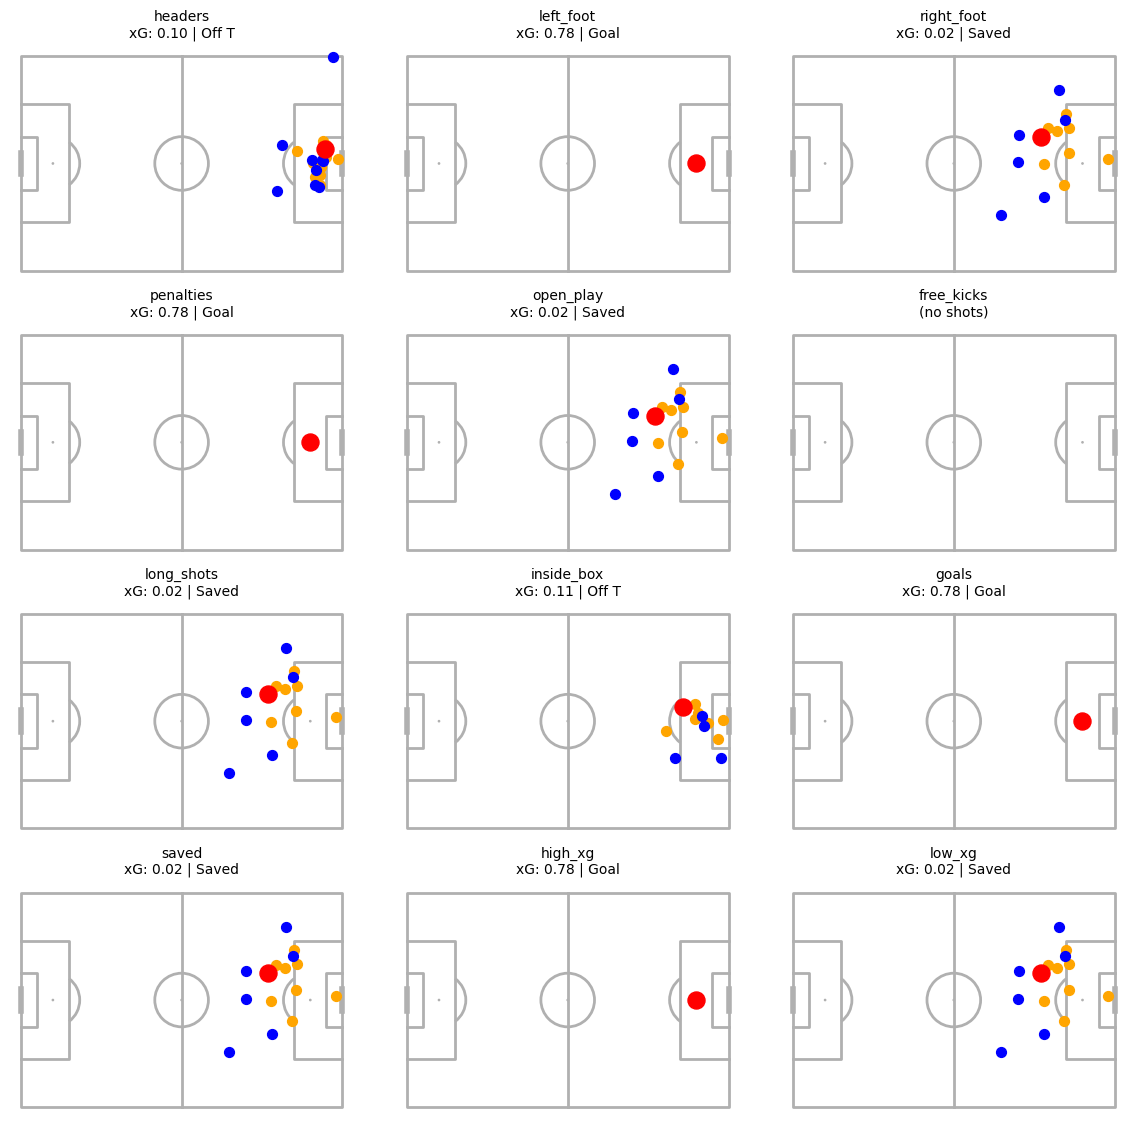

In [51]:
n_groups = len(shot_groups)
n_cols = 3
n_rows = (n_groups + n_cols - 1) // n_cols    #ceiling division

pitch = Pitch(pitch_type='statsbomb')

# pitch.grid returns a dict with 'fig' and 'axes'

fig, axs = pitch.grid(
    nrows = n_rows,
    ncols = n_cols,
    figheight = 15,
    space = 0.12,
    title_height = 0,
    endnote_height = 0,
    axis = False,
)

if isinstance(axs, dict):
    axes = axs['pitch']
else:
    axes = axs

axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for idx, (name, group) in enumerate(shot_groups.items()):
    ax = axes.flat[idx]
    if len(group) == 0:
        ax.set_title(f"{name}\n(no shots)", fontsize=10)
        continue

    shot = group.iloc[0]
    shot_loc = shot['location']
    freeze_frame = shot['shot_freeze_frame']


    #plotting shooter
    pitch.scatter(shot_loc[0], shot_loc[1], ax=ax, color='red', s=150, zorder=3)

    #plotting freeze frame players 
    if isinstance(freeze_frame, list):
        for player in freeze_frame:
            loc = player['location']
            color = 'blue' if player['teammate'] else 'orange' 
            pitch.scatter(loc[0], loc[1], ax=ax, color=color, s=50, zorder=2)

    ax.set_title(
        f"{name}\nxG: {shot['shot_statsbomb_xg']:.2f} | {shot['shot_outcome']}", fontsize=10
    )

# Hide any unused subplots 
for idx in range(len(shot_groups), len(axes_flat)):
    axes_flat[idx].axis('off')

plt.tight_layout()
plt.show()